In [20]:
# General settings

SERIES_LEN = 512
SYN_N_CHANNELS = 4
L_MIN = 256
L_MAX = 256 

In [21]:
import os

NUM_SERIES = 5000
DATA_DIR = "../DATA"
INNER_DIR = "analysis"

def create_remove_data_file(data_file: str):
    data_path = os.path.join(DATA_DIR, data_file)
    if os.path.exists(data_path):
        os.remove(data_path)

def get_csv_files(csvs_dir: str, ending: str = ".csv"):
    csv_files = [f"{csvs_dir}/{f}" for f in os.listdir(csvs_dir) if f.endswith(ending)]
    return " ".join(csv_files)

data_files = []
data_n_channels = []

# Create synthetic data
data_file = f"{INNER_DIR}/mts/test.bin"
data_files.append(data_file)
create_remove_data_file(data_file)
!../build/mulisse create_ds -d {data_file} -n {NUM_SERIES} -m {SERIES_LEN} -c {SYN_N_CHANNELS}
data_n_channels.append(SYN_N_CHANNELS)
print(f"Generated synthetic data file: {data_file}")

# Create stocks data
csv_files_str = get_csv_files("../../DATA/mulisse_pack/stocks", ".csv")
data_file = f"{INNER_DIR}/stocks/test.bin"
data_files.append(data_file)
create_remove_data_file(data_file)
!../build/mulisse parse_csv -d {data_file} -i {csv_files_str} -l {L_MIN} -m {SERIES_LEN} -n {NUM_SERIES}
data_n_channels.append(len(csv_files_str.split()))
print(f"Generated stocks data file: {data_file}")

# Create weather data
csv_files_str = get_csv_files("../../DATA/mulisse_pack/weather", "")
data_file = f"{INNER_DIR}/weather/test.bin"
data_files.append(data_file)
create_remove_data_file(data_file)
!../build/mulisse parse_csv -d {data_file} -i {csv_files_str} -l {L_MIN} -m {SERIES_LEN} -n {NUM_SERIES}
data_n_channels.append(len(csv_files_str.split()))
print(f"Generated weather data file: {data_file}")
    
print()
for data_file in data_files:
    data_path = os.path.join(DATA_DIR, data_file)
    if os.path.exists(data_path):
        print(f"Data file {data_file} created successfully")

print(f"Num channels per dataset: {data_n_channels}")

Generated synthetic data file: analysis/mts/test.bin
Generated stocks data file: analysis/stocks/test.bin
Generated weather data file: analysis/weather/test.bin

Data file analysis/mts/test.bin created successfully
Data file analysis/stocks/test.bin created successfully
Data file analysis/weather/test.bin created successfully
Num channels per dataset: [4, 5, 4]


In [22]:
import os

USE_ALL_CHANNELS = True
NUM_QUERIES = 1000

query_files = [os.path.dirname(data_file) + "/query.txt" for data_file in data_files]

for data_file, query_file, n_channels in zip(data_files, query_files, data_n_channels):
    used_channels = n_channels if USE_ALL_CHANNELS else 0
    !../build/mulisse create_qs -d {data_file} -q {query_file} -m {SERIES_LEN} -c {n_channels} \
        -l {L_MIN} -L {L_MAX} -Q {NUM_QUERIES} -u {used_channels} --noise 0.1
    print(f"Generated query file: {query_file}")

print()
for query_file in query_files:
    query_path = os.path.join(DATA_DIR, query_file)
    if os.path.exists(query_path):
        print(f"Query file {query_path} created successfully")

Generated query file: analysis/mts/query.txt
Generated query file: analysis/stocks/query.txt
Generated query file: analysis/weather/query.txt

Query file ../DATA/analysis/mts/query.txt created successfully
Query file ../DATA/analysis/stocks/query.txt created successfully
Query file ../DATA/analysis/weather/query.txt created successfully


In [23]:
from matplotlib import pyplot as plt
import numpy as np

MTS = np.ndarray[np.ndarray[float]]

def load_query(query_file: str, index: int, n_channels: int) -> MTS:
    with open(os.path.join(DATA_DIR, query_file), 'r') as f:
        lines = f.readlines()
        start = index * n_channels
        return np.array([list(map(float, l.split())) for l in lines[start:start + n_channels]])

def normalize_series(series: MTS) -> MTS:
    mu = np.mean(series, axis=1)
    sigma = np.std(series, axis=1)
    return [(s - mu[i]) / sigma[i] for i, s in enumerate(series)]

def plot_series(series: MTS, title: str):
    plt.figure(figsize=(10, 6))
    
    for s in series:
        plt.plot(s)
    
    plt.title(title)
    plt.xlabel('Index')
    plt.ylabel('Value')
    plt.legend([f'Channel {i+1}' for i in range(len(series))])
    plt.grid(True)
    plt.show()

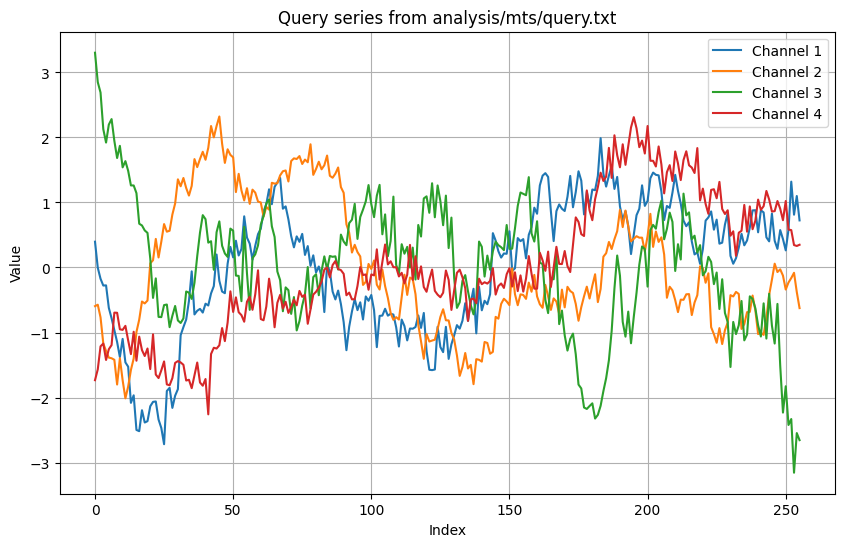

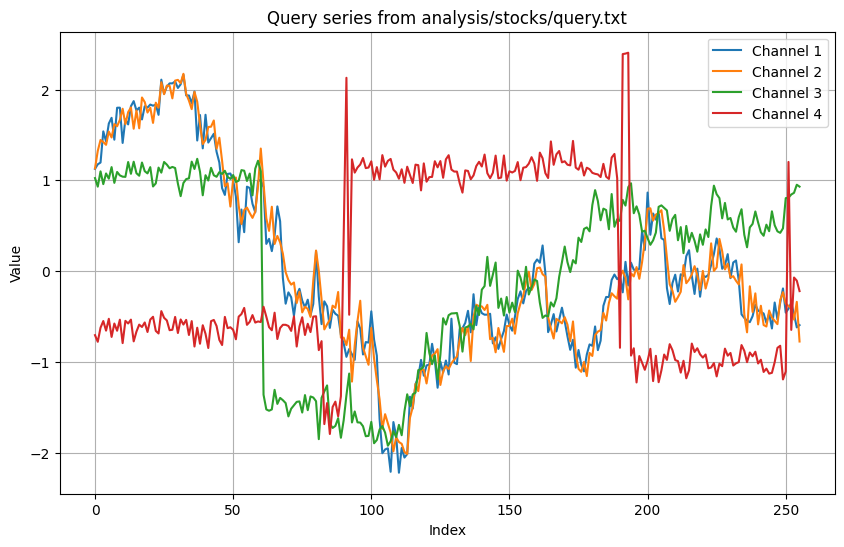

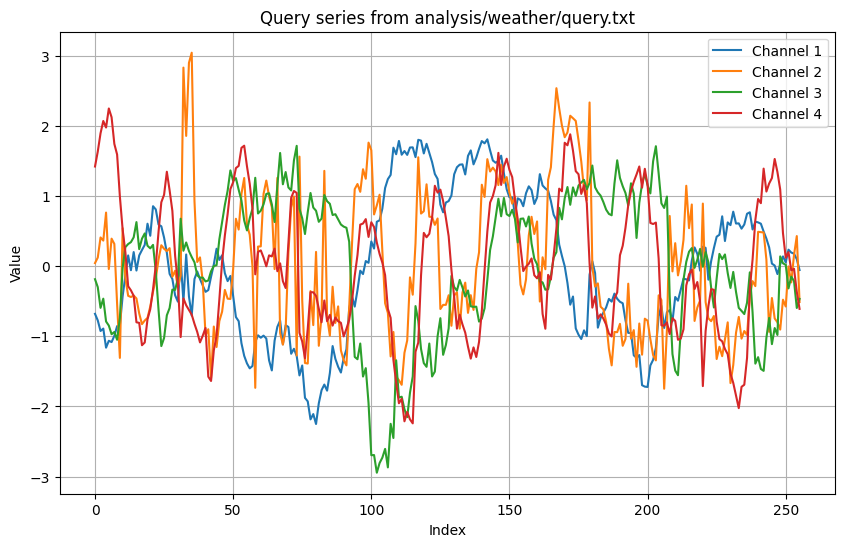

In [24]:
from random import randint

for i, query_file in enumerate(query_files):
    query_ind = randint(0, NUM_QUERIES - 1)
    query = load_query(query_file, query_ind, data_n_channels[0])
    query_normalized = normalize_series(query)
    plot_series(normalize_series(query), f"Query series from {query_file}")

In [25]:
from scipy.stats import kurtosis

query_file_avg_kurtosis = []
for i in range(len(query_files)):
    query_file_avg_kurtosis.append([0] * data_n_channels[i])

for i, query_file in enumerate(query_files):
    for j in range(NUM_QUERIES):
        query = load_query(query_file, j, data_n_channels[i])
        query_normalized = normalize_series(query)

        for k, channel in enumerate(query_normalized):
            query_file_avg_kurtosis[i][k] += kurtosis(channel)
    
    for k in range(len(query_file_avg_kurtosis[i])):
        query_file_avg_kurtosis[i][k] /= NUM_QUERIES


In [26]:
for i, query_file in enumerate(query_files):
    print(f"Average kurtosis for {query_file}: [")
    for k, avg_kurtosis in enumerate(query_file_avg_kurtosis[i]):
        print(f"    Channel {k+1}: {avg_kurtosis}")
    print("]")

Average kurtosis for analysis/mts/query.txt: [
    Channel 1: -0.5680979207744777
    Channel 2: -0.5682341381337396
    Channel 3: -0.571205765933704
    Channel 4: -0.6110349309092755
]
Average kurtosis for analysis/stocks/query.txt: [
    Channel 1: -0.21213344908201895
    Channel 2: 26.88982404786399
    Channel 3: -0.18143309982154335
    Channel 4: -0.25831702560268804
    Channel 5: -0.1675334392658351
]
Average kurtosis for analysis/weather/query.txt: [
    Channel 1: -0.4485651109001018
    Channel 2: 0.830775493435404
    Channel 3: -0.18302184808836222
    Channel 4: -0.14482935448191336
]
